In [40]:
pip install pandas sqlalchemy requests duckdb matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/eb/f8/6d0c312c8d9738e7d9677f09fe5c986b3239e651a7b73a2deb38b65e4a71/matplotlib-3.11.1-cp312-cp312-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.8 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/53/3e/405b59cfa13021a56bba395a6b3aca8cec012b45bf177b0eaf7a202cde2c/contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.28.2 from https://files.pythonhosted.org/packages/08/ef/b3c6b9b5be2f82416d73fe2ed2e96e2793cd80e7510bd6a17ca79cdd88ec/fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
import requests
import os
import sqlite3

RAW_DATA_DIR = "../data/rawData/"
CLEAN_DATA_DIR = "../data/clean_zone/"
REPORT_DIR = "../data/reports/"

CHINOOK_DB = os.path.join(RAW_DATA_DIR, "chinook.db")
NORTHWIND_DB = os.path.join(RAW_DATA_DIR, "northwind.db")

def list_tables(db_file):
    """
    Connects to a SQLite database and prints a list of all tables.

    Args:
        db_file (str): The path to the SQLite database file.
    """
    print("-" * 30)
    print(f"Listing tables in '{db_file}':")
    try:
        # Connect to the database
        conn = sqlite3.connect(db_file)
        cursor = conn.cursor()

        # Execute the query to find all tables in the database
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()

        if tables:
            for table in tables:
                print(f"- {table[0]}")
        else:
            print("No tables found in this database.")

        # Close the connection
        conn.close()
    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        print("-" * 30)

# List the tables in each database
list_tables(CHINOOK_DB)
list_tables(NORTHWIND_DB)

------------------------------
Listing tables in '../data/rawData/chinook.db':
- Album
- Artist
- Customer
- Employee
- Genre
- Invoice
- InvoiceLine
- MediaType
- Playlist
- PlaylistTrack
- Track
------------------------------
------------------------------
Listing tables in '../data/rawData/northwind.db':
- Categories
- sqlite_sequence
- CustomerCustomerDemo
- CustomerDemographics
- Customers
- Employees
- EmployeeTerritories
- Order Details
- Orders
- Products
- Regions
- Shippers
- Suppliers
- Territories
------------------------------


In [25]:
from sqlalchemy import create_engine
import pandas as pd

# Create an SQLAlchemy engine for the Chinook database
chinook_engine = create_engine("sqlite:///../data/rawData/chinook.db", echo=False)

# A connection can be explicitly opened and closed
chinook_conn = chinook_engine.connect()

# Or, as a best practice, use a 'with' statement for automatic resource management
with chinook_engine.connect() as conn:
    print("Connection to Chinook database established successfully.")
    # All database operations would happen here
    pass

chinook_conn.close() # Close the explicit connection

northwind_engine = create_engine("sqlite:///../data/rawData/northwind.db", echo=False)
northwind_conn = northwind_engine.connect()

with northwind_engine.connect() as conn:
    print("Connection to Nortwind database established successfully.")
    # All database operations would happen here
    pass

northwind_conn.close() # Close the explicit connection

Connection to Chinook database established successfully.
Connection to Nortwind database established successfully.


In [26]:
from sqlalchemy import inspect

def list_columns_in_database(engine, db_name):
    """
    Connects to a database and prints a list of all tables and their columns.

    Args:
        engine (sqlalchemy.engine.base.Engine): The SQLAlchemy engine for the database.
        db_name (str): The name of the database (for printing purposes).
    """
    print("-" * 30)
    print(f"Listing tables and columns in '{db_name}':")
    try:
        inspector = inspect(engine)
        table_names = inspector.get_table_names()

        if table_names:
            for table_name in table_names:
                print(f"\nTable: {table_name}")
                columns = inspector.get_columns(table_name)
                for column in columns:
                    print(f"  - {column['name']} ({column['type']})")
        else:
            print("No tables found in this database.")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        print("-" * 30)

# List tables and columns for Chinook database
list_columns_in_database(chinook_engine, CHINOOK_DB)

# List tables and columns for Northwind database
list_columns_in_database(northwind_engine, NORTHWIND_DB)

------------------------------
Listing tables and columns in '../data/rawData/chinook.db':

Table: Album
  - AlbumId (INTEGER)
  - Title (NVARCHAR(160))
  - ArtistId (INTEGER)

Table: Artist
  - ArtistId (INTEGER)
  - Name (NVARCHAR(120))

Table: Customer
  - CustomerId (INTEGER)
  - FirstName (NVARCHAR(40))
  - LastName (NVARCHAR(20))
  - Company (NVARCHAR(80))
  - Address (NVARCHAR(70))
  - City (NVARCHAR(40))
  - State (NVARCHAR(40))
  - Country (NVARCHAR(40))
  - PostalCode (NVARCHAR(10))
  - Phone (NVARCHAR(24))
  - Fax (NVARCHAR(24))
  - Email (NVARCHAR(60))
  - SupportRepId (INTEGER)

Table: Employee
  - EmployeeId (INTEGER)
  - LastName (NVARCHAR(20))
  - FirstName (NVARCHAR(20))
  - Title (NVARCHAR(30))
  - ReportsTo (INTEGER)
  - BirthDate (DATETIME)
  - HireDate (DATETIME)
  - Address (NVARCHAR(70))
  - City (NVARCHAR(40))
  - State (NVARCHAR(40))
  - Country (NVARCHAR(40))
  - PostalCode (NVARCHAR(10))
  - Phone (NVARCHAR(24))
  - Fax (NVARCHAR(24))
  - Email (NVARCHAR(60))

In [34]:
chinook_artists_df = pd.read_sql_table('Artist', con=chinook_engine, )
print("\nChinook Artists DataFrame loaded successfully.")
chinook_artists_df.head()


Chinook Artists DataFrame loaded successfully.


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains


In [35]:


# 2. อ่านข้อมูล
northwind_employees_df = pd.read_sql_query("SELECT * FROM Employees", con=northwind_engine)
print("Northwind Employees DataFrame loaded successfully.")

# 3. แสดงผล
northwind_employees_df.head()

Northwind Employees DataFrame loaded successfully.


,EmployeeID,LastName,FirstName,Title,TitleOfCourtesy,BirthDate,HireDate,Address,City,Region,PostalCode,Country,HomePhone,Extension,Photo,Notes,ReportsTo,PhotoPath
0,1,Davolio,Nancy,Sales Representative,Ms.,1968-12-08,2012-05-01,507 - 20th Ave. E.Apt. 2A,Seattle,North America,98122,USA,(206) 555-9857,5467,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Education includes a BA in psychology from Col...,2.0,http://accweb/emmployees/davolio.bmp
1,2,Fuller,Andrew,"Vice President, Sales",Dr.,1972-02-19,2012-08-14,908 W. Capital Way,Tacoma,North America,98401,USA,(206) 555-9482,3457,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Andrew received his BTS commercial in 1974 and...,NaN,http://accweb/emmployees/fuller.bmp
2,3,Leverling,Janet,Sales Representative,Ms.,1983-08-30,2012-04-01,722 Moss Bay Blvd.,Kirkland,North America,98033,USA,(206) 555-3412,3355,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Janet has a BS degree in chemistry from Boston...,2.0,http://accweb/emmployees/leverling.bmp
3,4,Peacock,Margaret,Sales Representative,Mrs.,1957-09-19,2013-05-03,4110 Old Redmond Rd.,Redmond,North America,98052,USA,(206) 555-8122,5176,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Margaret holds a BA in English literature from...,2.0,http://accweb/emmployees/peacock.bmp
4,5,Buchanan,Steven,Sales Manager,Mr.,1975-03-04,2013-10-17,14 Garrett Hill,London,British Isles,SW1 8JR,UK,(71) 555-4848,3453,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Steven Buchanan graduated from St. Andrews Uni...,2.0,http://accweb/emmployees/buchanan.bmp


In [36]:
artists_albums_query = """
SELECT
    T1.Name AS ArtistName,
    T2.Title AS AlbumTitle
FROM Artist AS T1
JOIN Album AS T2
    ON T1.ArtistId = T2.ArtistId
ORDER BY
    ArtistName
LIMIT 10;
"""
artists_albums_df = pd.read_sql_query(artists_albums_query, con=chinook_engine)
print("\nDataFrame of Chinook artists and their albums loaded successfully.")
artists_albums_df


DataFrame of Chinook artists and their albums loaded successfully.


,ArtistName,AlbumTitle
0,AC/DC,For Those About To Rock We Salute You
1,AC/DC,Let There Be Rock
2,Aaron Copland & London Symphony Orchestra,"A Copland Celebration, Vol. I"
3,Aaron Goldberg,Worlds
4,Academy of St. Martin in the Fields & Sir Nevi...,The World of Classical Favourites
5,Academy of St. Martin in the Fields Chamber En...,Sir Neville Marriner: A Celebration
6,"Academy of St. Martin in the Fields, John Birc...","Fauré: Requiem, Ravel: Pavane & Others"
7,"Academy of St. Martin in the Fields, Sir Nevil...",Bach: Orchestral Suites Nos. 1 - 4
8,Accept,Balls to the Wall
9,Accept,Restless and Wild


In [37]:
chinook_artists_df.info()
chinook_artists_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ArtistId  275 non-null    int64 
 1   Name      275 non-null    object
dtypes: int64(1), object(1)
memory usage: 4.4+ KB


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains


In [38]:
print("\n--- Initial Inspection of Northwind Employees DataFrame ---")
print(f"DataFrame Shape: {chinook_artists_df.shape}\n")
print("Column Data Types:\n", chinook_artists_df.dtypes, "\n")
chinook_artists_df.info()


--- Initial Inspection of Northwind Employees DataFrame ---
DataFrame Shape: (275, 2)

Column Data Types:
 ArtistId     int64
Name        object
dtype: object 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ArtistId  275 non-null    int64 
 1   Name      275 non-null    object
dtypes: int64(1), object(1)
memory usage: 4.4+ KB


Matplotlib is building the font cache; this may take a moment.


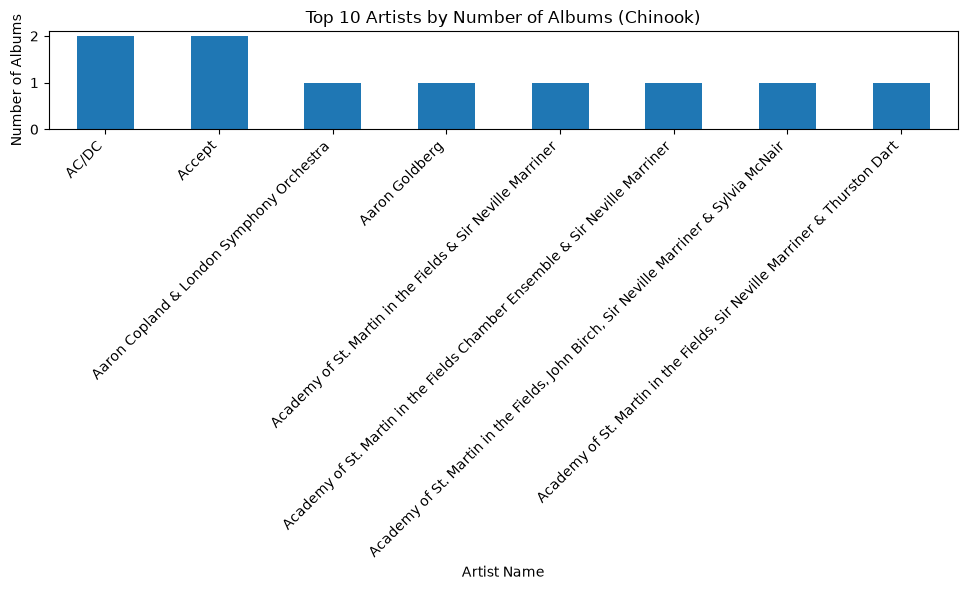

In [41]:
import matplotlib.pyplot as plt

# Get the count of albums per artist
albums_per_artist = artists_albums_df.groupby('ArtistName').size().sort_values(ascending=False)

# Select the top 10 artists by album count
top_10_artists = albums_per_artist.head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
top_10_artists.plot(kind='bar')
plt.title('Top 10 Artists by Number of Albums (Chinook)')
plt.xlabel('Artist Name')
plt.ylabel('Number of Albums')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
pd.options.display.float_format = '{:,.2f}'.format
northwind_total_revenue = """
SELECT SUM(UnitPrice * Quantity) AS GrossRevenue
FROM [Order Details];
"""
northwind_total_revenue_df = pd.read_sql_query(northwind_total_revenue, con=northwind_engine)

northwind_total_revenue_df

,GrossRevenue
0,"448,475,298.72"


In [53]:
chinook_total_revenue = """
SELECT SUM(UnitPrice * Quantity) AS GrossRevenue
FROM [InvoiceLine];
"""
chinook_total_revenue_df = pd.read_sql_query(chinook_total_revenue, con=chinook_engine)

chinook_total_revenue_df

,GrossRevenue
0,2328.6


In [ ]:
northwind_order_detail_df = pd.read_sql_query("SELECT * FROM [Order Details];", con=northwind_engine)
print("Northwind Order detail DataFrame loaded successfully.")

# 3. แสดงผล
northwind_order_detail_df


Northwind Order detail DataFrame loaded successfully.


In [57]:
northwind_order_detail_df = pd.read_sql_query("SELECT * FROM [Orders];", con=northwind_engine)
print("Northwind Order detail DataFrame loaded successfully.")

# 3. แสดงผล
northwind_order_detail_df


Northwind Order detail DataFrame loaded successfully.


,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2016-07-08,2016-08-05,2016-07-12,2,25.00,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2016-07-08,2016-08-05,2016-07-15,1,20.25,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2016-07-09,2016-08-06,2016-07-11,2,36.25,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16277,26525,WHITC,6,2012-12-26 04:58:22,2013-01-07 03:47:01,2012-12-28 19:03:24,1,42.50,Wellington Importadora,"Rua do Mercado, 12",Resende,South America,08737-363,Brazil
16278,26526,WOLZA,9,2022-08-05 06:33:39,2022-09-01 05:09:08,2022-08-10 08:11:43,2,425.50,Tortuga Restaurante,Avda. Azteca 123,México D.F.,Central America,5033,Mexico
16279,26527,GOURL,4,2022-02-09 08:20:12,2022-02-19 13:46:17,2022-02-23 07:40:46,3,280.00,France restauration,"54, rue Royale",Nantes,Western Europe,44000,France
16280,26528,BLONP,9,2020-04-27 23:05:30,2020-05-22 20:22:49,2020-04-28 11:21:50,2,131.25,Great Lakes Food Market,2732 Baker Blvd.,Eugene,North America,97403,USA


In [59]:
northwind_order_detail_df = pd.read_sql_query("SELECT LEFT(4,OrderDate) FROM [Orders];", con=northwind_engine)
print("Northwind Order detail DataFrame loaded successfully.")

# 3. แสดงผล
northwind_order_detail_df


OperationalError: (sqlite3.OperationalError) no such function: LEFT
[SQL: SELECT LEFT(4,OrderDate) FROM [Orders];]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [49]:
from data_quarity import estimate_dataframe 

estimate_dataframe(northwind_order_detail_df)



DATAFRAME ROW-LEVEL DUPLICATE SUMMARY
Total Rows: 609283
Duplicate Rows Count: 0
Duplicate Rows Percentage: 0.00%



,Data Type,Missing Count,Missing (%),Col Duplicate (%),Outlier Count,Outlier (%)
OrderID,int64,0,0.00%,97.33%,0,0.00%
ProductID,int64,0,0.00%,99.99%,0,0.00%
UnitPrice,float64,0,0.00%,99.98%,31622,5.19%
Quantity,int64,0,0.00%,99.99%,49,0.01%
Discount,float64,0,0.00%,100.00%,838,0.14%


In [50]:
import pandas as pd
import numpy as np

def check_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    result = []
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        count = len(outliers)
        pct = (count / len(df)) * 100 if len(df) > 0 else 0
        
        result.append({
            'column': col,
            'outlier_count': count,
            'outlier_percentage': round(pct, 2),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })
        
    return pd.DataFrame(result)

# ตัวอย่างการใช้งาน
# df_outliers = check_outliers_iqr(df)
# print(df_outliers)


In [51]:
df_outliers = check_outliers_iqr(northwind_order_detail_df)
print(df_outliers)

      column  outlier_count  outlier_percentage  lower_bound  upper_bound
0    OrderID              0                0.00      3246.00     34342.00
1  ProductID              0                0.00       -37.00       115.00
2  UnitPrice          31622                5.19       -16.75        63.25
3   Quantity             49                0.01       -24.50        75.50
4   Discount            838                0.14         0.00         0.00
